# Phase 3 — Training Loop & Naive Sampler

This notebook exercises the `dms` package built in Phase 3:

- `dms.train.train_model` — trains `BasicUNet` to denoise `corrupt()`-ed batches
- `dms.sample.sample` — the naive iterative sampler that turns pure noise into a digit-like image

As in Phase 2, this notebook uses real MNIST if network access allows it, and
falls back to `FakeData` otherwise so the mechanics (training loop, loss
curve, sampling loop) are still demonstrated end-to-end. **If you run this
with real MNIST, expect noticeably better (digit-shaped) samples than the
fallback shown here.**

In [1]:
import torch
from matplotlib import pyplot as plt

from dms.data import get_dataloader
from dms.models import BasicUNet, count_parameters
from dms.sample import sample
from dms.train import TrainConfig, save_checkpoint, train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print(f"Using device: {device}")

Using device: cpu


## The data

Same fallback strategy as Phase 2: try real MNIST, fall back to `FakeData`
(random images, correctly shaped) if the dataset mirrors aren't reachable.

In [2]:
batch_size = 64

try:
    train_dataloader = get_dataloader(name="mnist", root="data", batch_size=batch_size, download=True)
    x, y = next(iter(train_dataloader))
    using_real_data = True
except Exception as e:
    print(f"Falling back to FakeData (real MNIST unavailable: {e})")
    import torchvision
    fake = torchvision.datasets.FakeData(
        size=512, image_size=(1, 28, 28), num_classes=10, transform=torchvision.transforms.ToTensor()
    )
    train_dataloader = torch.utils.data.DataLoader(fake, batch_size=batch_size, shuffle=True)
    x, y = next(iter(train_dataloader))
    using_real_data = False

print("Batch shape:", x.shape, "| using real MNIST:", using_real_data)

Falling back to FakeData (real MNIST unavailable: Error downloading train-images-idx3-ubyte.gz:
Tried https://ossci-datasets.s3.amazonaws.com/mnist/, got:
HTTP Error 403: Forbidden
Tried http://yann.lecun.com/exdb/mnist/, got:
HTTP Error 403: Forbidden
)
Batch shape: torch.Size([64, 1, 28, 28]) | using real MNIST: False


## Train BasicUNet

A short run (a handful of epochs) just to demonstrate the pipeline works and
the loss trends down. A real training run (per the original notebook) uses
more epochs on the full MNIST training set for noticeably sharper samples.

In [3]:
net = BasicUNet()
print("Parameter count:", count_parameters(net))

config = TrainConfig(epochs=3, lr=1e-3, device=str(device), log_every=0)
result = train_model(net, train_dataloader, config)

print("Final epoch mean losses:", [round(l, 4) for l in result.epoch_mean_losses])

Parameter count: 309057


epoch 0: mean loss=0.1629


epoch 1: mean loss=0.1039


epoch 2: mean loss=0.0920
Final epoch mean losses: [0.1629, 0.1039, 0.092]


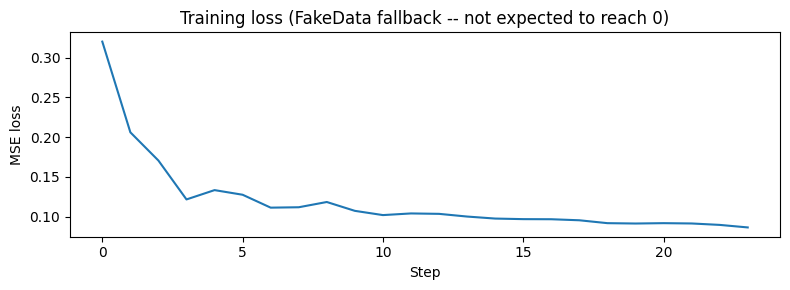

In [4]:
plt.figure(figsize=(8, 3))
plt.plot(result.losses)
plt.title("Training loss" + ("" if using_real_data else " (FakeData fallback -- not expected to reach 0)"))
plt.xlabel("Step")
plt.ylabel("MSE loss")
plt.tight_layout()
plt.savefig("../docs/assets/training_loss.png", dpi=100)
plt.show()

## Sample from the trained model

Start from pure noise and run the naive iterative sampler for a few step
counts, to see how the number of steps trades off against sample quality.

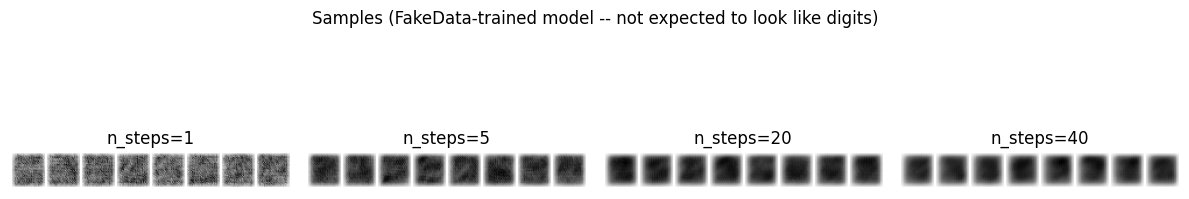

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
for ax, n_steps in zip(axs, [1, 5, 20, 40]):
    samples = sample(net, n_steps=n_steps, shape=(8, 1, 28, 28), device=str(device))
    grid = torchvision_make_grid = __import__("torchvision").utils.make_grid(samples.clamp(0, 1))
    ax.imshow(grid.permute(1, 2, 0)[..., 0], cmap="Greys")
    ax.set_title(f"n_steps={n_steps}")
    ax.axis("off")
plt.suptitle("Samples" + ("" if using_real_data else " (FakeData-trained model -- not expected to look like digits)"))
plt.tight_layout()
plt.savefig("../docs/assets/samples_by_step_count.png", dpi=100)
plt.show()

## Visualize the denoising trajectory

Using `return_intermediates=True` to see how a single sample evolves from
noise to (attempted) digit, step by step.

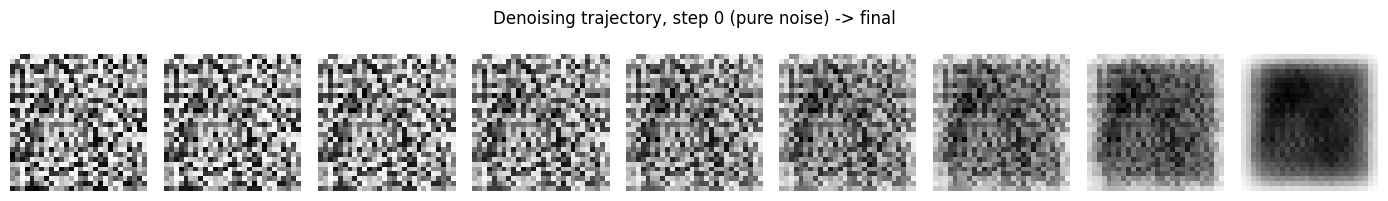

In [6]:
result_traj = sample(net, n_steps=8, shape=(1, 1, 28, 28), device=str(device), return_intermediates=True)

fig, axs = plt.subplots(1, len(result_traj.step_history), figsize=(14, 2))
for ax, step_x in zip(axs, result_traj.step_history):
    ax.imshow(step_x[0, 0].clamp(0, 1), cmap="Greys")
    ax.axis("off")
plt.suptitle("Denoising trajectory, step 0 (pure noise) -> final")
plt.tight_layout()
plt.savefig("../docs/assets/denoising_trajectory.png", dpi=100)
plt.show()

## Save a checkpoint

So Phase 4's DDPM comparison (or anyone re-running this later) can load
these weights without retraining.

In [7]:
save_checkpoint(net, "../checkpoints/basic_unet_phase3.pt")
print("Saved to ../checkpoints/basic_unet_phase3.pt")

Saved to ../checkpoints/basic_unet_phase3.pt


## Next steps

This notebook covers Phase 3: training `BasicUNet` and sampling from it with
the naive iterative sampler. Phase 4 swaps in `diffusers`' `UNet2DModel` and
`DDPMScheduler` to show what a principled (Gaussian noise, timestep-conditioned,
scheduled) diffusion model changes relative to this toy version -- see
`03_ddpm_comparison.ipynb` and `docs/COMPARISON.md`, added in Phase 4.